In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chemevo import evolution_V1 as evo
from chemevo.iterative_1D_method import get_sampled_gals
import chemevo.plotstyle

chemevo.plotstyle.use()

In [79]:
best_fits_low_res = pd.read_csv("convergence_test_output/convergence_summary.csv")
best_fits_low_res = best_fits_low_res.drop_duplicates(subset="reduced_chi2", keep='first')
best_fits_low_res = best_fits_low_res.sort_values(by='reduced_chi2', ascending=True)
best_fits_low_res

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
1,alpha_cc,0.2,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
0,alpha_cc,0.1,0.3,0.4,1.8,0.3,0.5,0.4,1.7,0.011581
28,g_ratio,0.4,0.3,0.4,1.0,0.4,0.1,0.4,1.4,0.012296
30,g_ratio,0.4,0.3,0.4,1.5,0.3,0.3,0.4,1.5,0.013440
22,g_cc,0.4,0.3,0.5,1.8,0.5,0.3,0.5,1.2,0.013491
26,g_cc,0.4,0.3,0.9,1.8,0.4,0.5,0.5,1.2,0.016955
16,alpha_Ia,0.4,0.8,0.4,1.8,0.2,0.8,0.4,1.8,0.018915


In [80]:
from chemevo.iterative_1D_method import find_best_model

## Perturbing the best-fit params and measuring reduced chi^2

No optimization here - just build the best-fit model plus, for each of the
four metdep params, a model with that one param nudged by +/-0.01 (the
other three held at their best-fit values), and measure each model's
reduced chi^2 against the data. Reuses `make_models`/`find_best_model` from
`chemevo.iterative_1D_method` (grid_size=0.01, grid_len=3 gives exactly
best-0.01, best, best+0.01) rather than re-implementing the model-building
or chi^2 logic.

In [81]:
import os

from chemevo import iterative_1D_method
from chemevo.mn_fe_lines import load_mn_fe_lines

lines_df = load_mn_fe_lines()

PARAMS = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]
PERTURBATION = 0.01
BESTFIT_ROW = 4
OUTPUT_DIR = f"chi2_gridsize_{PERTURBATION}_bestfit_row_{BESTFIT_ROW}"

best_row = best_fits_low_res.iloc[BESTFIT_ROW]
best_values = {
    "alpha_cc": best_row["best_alpha_cc"],
    "alpha_Ia": best_row["best_alpha_Ia"],
    "g_cc": best_row["best_g_cc"],
    "g_ratio": best_row["best_g_ratio"],
}
best_values

{'alpha_cc': np.float64(0.3),
 'alpha_Ia': np.float64(0.5),
 'g_cc': np.float64(0.4),
 'g_ratio': np.float64(1.7000000000000002)}

In [82]:
def measure_chi2_for_param(param, best_values, perturbation, output_dir):
    """
    Build 3 models for `param` = best_values[param] - perturbation, exactly
    best_values[param], and best_values[param] + perturbation, holding the
    other three params fixed at their best-fit values. Measure each one's
    reduced chi^2 against the data. This does not search for a best value -
    it just evaluates these three specific points.

    Returns a DataFrame with columns [param, "reduced_chi2"], one row per
    perturbed value.
    """
    os.makedirs(output_dir, exist_ok=True)

    # grid_size=perturbation, grid_len=3 gives exactly 3 points, spaced
    # `perturbation` apart, centered on best_values[param]: that's
    # best-perturbation, best, best+perturbation.
    iterative_1D_method.make_models(
        param_to_optimize=param,
        t_array=iterative_1D_method.t_array,
        sfrs=iterative_1D_method.sfrs,
        etas=iterative_1D_method.etas,
        tau_stars=iterative_1D_method.tau_stars,
        alpha_cc_init=best_values["alpha_cc"],
        alpha_Ia_init=best_values["alpha_Ia"],
        g_cc_init=best_values["g_cc"],
        g_ratio_init=best_values["g_ratio"],
        grid_size=perturbation,
        grid_len=3,
        iter=0,
        save_dir=output_dir,
        save="on",
    )

    # make_models wrote one CSV per perturbed value, named
    # "{param}_iter0_{value}.csv" inside output_dir - find them.
    file_prefix = f"{param}_iter0"
    filepath_list = []
    for filename in os.listdir(output_dir):
        if filename.startswith(file_prefix) and filename.endswith(".csv"):
            filepath_list.append(os.path.join(output_dir, filename))

    iterative_1D_method.find_best_model(
        filepath_list=filepath_list, param=param, iter=0,
        output_path=output_dir + os.sep, data=lines_df,
    )

    chi2_path = os.path.join(output_dir, f"chi_2_results_{param}_iter_0.csv")
    chi2_df = pd.read_csv(chi2_path)
    chi2_df = chi2_df.sort_values(by=param)
    return chi2_df[[param, "reduced_chi2"]].reset_index(drop=True)

In [83]:
chi2_by_param = {}
for param in PARAMS:
    chi2_by_param[param] = measure_chi2_for_param(param, best_values, PERTURBATION, OUTPUT_DIR)

for param in PARAMS:
    print(param)
    print(chi2_by_param[param])
    print()

alpha_ccs =  [0.29 0.3  0.31]
n_gals in each alpha_cc =  300
n_gals total =  900
Done generating models for alpha_cc, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for alpha_cc, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for alpha_cc, iter = 0, grid size = 0.01, grid_len = 3
alpha_Ias =  [0.49 0.5  0.51]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for alpha_Ia, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for alpha_Ia, iter = 0, grid size = 0.01, grid_len = 3
g_ccs =  [0.39 0.4  0.41]
n_gals in each g_cc =  300
n_gals total =  900
Done generating models for g_cc, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for g_cc, iter = 0, grid size = 0.01, grid_len = 3
Done generating models for g_cc, iter = 0, grid size = 0.01, grid_len = 3
g_ratios =  [1.69 1.7  1.71]
n_gals in each g_ratio =  300
n_gals total =  

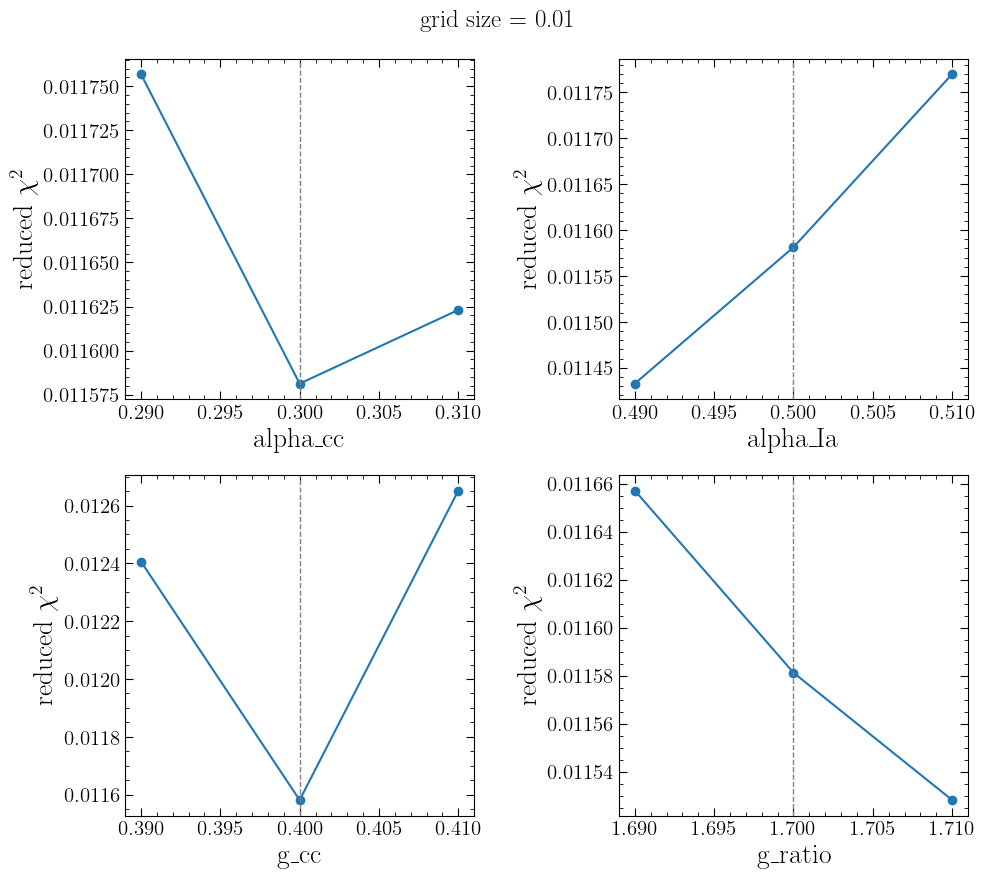

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, param in zip(axes.flat, PARAMS):
    df = chi2_by_param[param]
    ax.plot(df[param], df["reduced_chi2"], marker="o")
    ax.axvline(best_values[param], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(param)
    ax.set_ylabel(r"reduced $\chi^2$")

plt.suptitle(f"grid size = {PERTURBATION}")
plt.tight_layout()
plt.show()